<a href="https://colab.research.google.com/github/Umer-Ashfaq/AI-600/blob/main/24280004_PA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import pandas as pd
from sklearn.metrics import accuracy_score

In [ ]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 256
EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [ ]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [ ]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [ ]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================
import time
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def count_params(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for batch in loader:
        x, y = batch
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / max(1, n_batches), total_acc / max(1, n_batches)

def plot_curves(history, title="Training Curves"):
    # history keys: train_loss, val_loss, train_acc, val_acc
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(list(epochs), history["train_loss"], label="train_loss")
    plt.plot(list(epochs), history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(list(epochs), history["train_acc"], label="train_acc")
    plt.plot(list(epochs), history["val_acc"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def train_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=20,
    lr=1e-3,
    weight_decay=0.0,
    patience=7,
    max_grad_norm=1.0,
    use_scheduler=True,
    model_name="model"
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_acc = -1.0
    best_state = None
    bad_epochs = 0

    for ep in range(1, epochs + 1):
        model.train()
        t0 = time.time()

        running_loss = 0.0
        running_acc = 0.0
        n_batches = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()

            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            running_loss += loss.item()
            running_acc += accuracy_from_logits(logits, y)
            n_batches += 1

        train_loss = running_loss / max(1, n_batches)
        train_acc = running_acc / max(1, n_batches)

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        dt = time.time() - t0
        print(
            f"[{model_name}] Epoch {ep:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {dt:.1f}s"
        )

        # Early stopping on val accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{model_name}] Early stopping triggered.")
                break

    # Restore best
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_acc

In [ ]:
# Dataset + Dataloaders

full_train = QuickDrawDataset(TRAIN_FILE, mode="train")
num_classes = len(full_train.classes)
print("Detected num_classes:", num_classes)

# Split into train/val
val_ratio = 0.15
n_total = len(full_train)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(full_train, [n_train, n_val], generator=generator)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Test dataset
test_ds = QuickDrawDataset(TEST_FILE, mode="test")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Detected num_classes: 15
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.


In [ ]:
# MLP Model Builder
class MLP(nn.Module):
    """
    Generic MLP:
      - flattens 28x28 -> 784
      - supports BatchNorm + Dropout between Linear layers
    """
    def __init__(
        self,
        input_size=784,
        num_classes=15,
        hidden_sizes=(512, 256),
        activation="relu",
        dropout=0.0,
        use_batchnorm=False,
    ):
        super().__init__()
        self.input_size = input_size
        self.num_classes = num_classes
        self.use_batchnorm = use_batchnorm

        act = activation.lower()
        if act == "relu":
            self.act_fn = nn.ReLU()
        elif act == "leakyrelu":
            self.act_fn = nn.LeakyReLU(0.1)
        elif act == "gelu":
            self.act_fn = nn.GELU()
        else:
            raise ValueError("activation must be one of: relu, leakyrelu, gelu")

        layers = []
        in_dim = input_size

        for i, h in enumerate(hidden_sizes):
            layers.append(nn.Linear(in_dim, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(self.act_fn)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

        # Better init helps deep MLPs a bit
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):

        x = x.view(x.size(0), -1)
        return self.net(x)

In [ ]:
# Part A: Pancake
pancake = MLP(
    input_size=784,
    num_classes=num_classes,
    hidden_sizes=(1024,),
    activation="relu",
    dropout=0.40,
    use_batchnorm=False
).to(DEVICE)

# Part B: Tower
tower = MLP(
    input_size=784,
    num_classes=num_classes,
    hidden_sizes=(256, 256, 256, 256, 256, 256),
    activation="leakyrelu",
    dropout=0.35,
    use_batchnorm=True
).to(DEVICE)

# Part C: Champion (tuned)
champion = MLP(
    input_size=784,
    num_classes=num_classes,
    hidden_sizes=(512, 256, 256),
    activation="relu",
    dropout=0.45,
    use_batchnorm=True
).to(DEVICE)

models = {
    "Pancake": pancake,
    "Tower": tower,
    "Champion": champion
}

for name, m in models.items():
    p = count_params(m)
    print(f"{name} params: {p:,}")
    if p > 3_000_000:
        raise ValueError(f"{name} exceeds 3M parameter limit: {p:,}")

Pancake params: 819,215
Tower params: 536,847
Champion params: 604,943


[Pancake] Epoch 01/20 | train_loss=1.5528 train_acc=0.6065 | val_loss=1.3657 val_acc=0.6904 | 1.8s
[Pancake] Epoch 02/20 | train_loss=1.3315 train_acc=0.6997 | val_loss=1.2926 val_acc=0.7212 | 1.3s
[Pancake] Epoch 03/20 | train_loss=1.2561 train_acc=0.7346 | val_loss=1.2552 val_acc=0.7318 | 1.3s
[Pancake] Epoch 04/20 | train_loss=1.2070 train_acc=0.7565 | val_loss=1.2284 val_acc=0.7474 | 1.3s
[Pancake] Epoch 05/20 | train_loss=1.1650 train_acc=0.7760 | val_loss=1.2182 val_acc=0.7461 | 1.4s
[Pancake] Epoch 06/20 | train_loss=1.1308 train_acc=0.7931 | val_loss=1.2143 val_acc=0.7534 | 1.3s
[Pancake] Epoch 07/20 | train_loss=1.1024 train_acc=0.8061 | val_loss=1.1979 val_acc=0.7591 | 1.3s
[Pancake] Epoch 08/20 | train_loss=1.0766 train_acc=0.8172 | val_loss=1.2065 val_acc=0.7631 | 1.3s
[Pancake] Epoch 09/20 | train_loss=1.0531 train_acc=0.8285 | val_loss=1.1925 val_acc=0.7623 | 2.1s
[Pancake] Epoch 10/20 | train_loss=1.0333 train_acc=0.8368 | val_loss=1.2067 val_acc=0.7619 | 1.5s
[Pancake] 

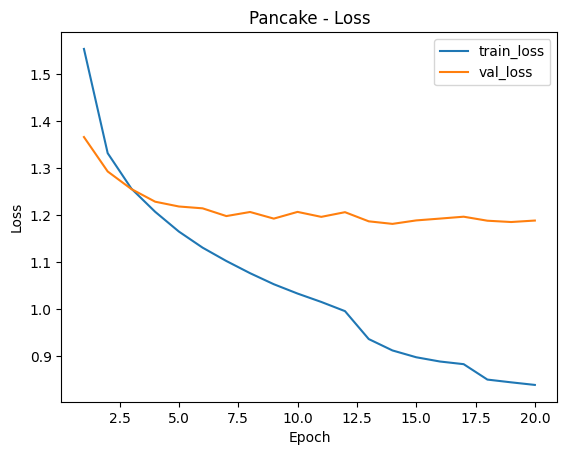

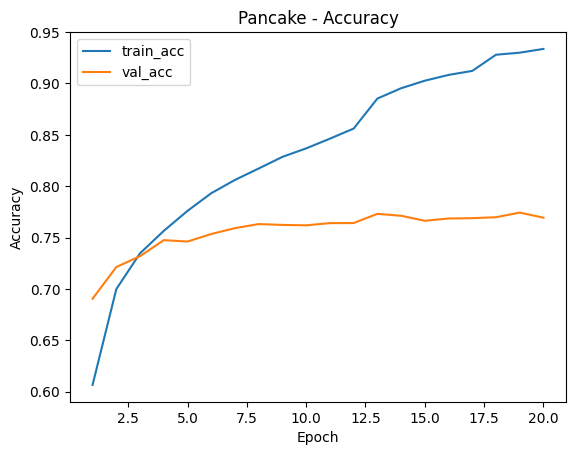

[Tower] Epoch 01/30 | train_loss=2.1266 train_acc=0.3649 | val_loss=1.4982 val_acc=0.6160 | 2.0s
[Tower] Epoch 02/30 | train_loss=1.5847 train_acc=0.5739 | val_loss=1.3750 val_acc=0.6665 | 2.0s
[Tower] Epoch 03/30 | train_loss=1.4791 train_acc=0.6241 | val_loss=1.3239 val_acc=0.6806 | 2.0s
[Tower] Epoch 04/30 | train_loss=1.4212 train_acc=0.6460 | val_loss=1.2920 val_acc=0.6997 | 2.6s
[Tower] Epoch 05/30 | train_loss=1.3833 train_acc=0.6614 | val_loss=1.2656 val_acc=0.7102 | 2.0s
[Tower] Epoch 06/30 | train_loss=1.3489 train_acc=0.6773 | val_loss=1.2483 val_acc=0.7128 | 1.9s
[Tower] Epoch 07/30 | train_loss=1.3249 train_acc=0.6883 | val_loss=1.2382 val_acc=0.7227 | 1.9s
[Tower] Epoch 08/30 | train_loss=1.3017 train_acc=0.6968 | val_loss=1.2284 val_acc=0.7213 | 1.9s
[Tower] Epoch 09/30 | train_loss=1.2857 train_acc=0.7045 | val_loss=1.2191 val_acc=0.7279 | 1.9s
[Tower] Epoch 10/30 | train_loss=1.2673 train_acc=0.7114 | val_loss=1.2116 val_acc=0.7304 | 2.5s
[Tower] Epoch 11/30 | train_lo

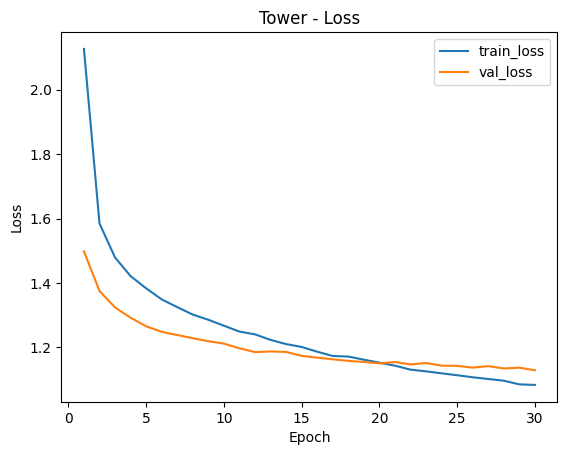

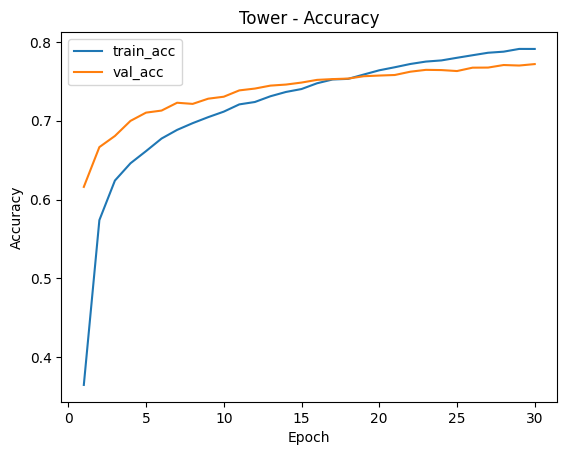

[Champion] Epoch 01/30 | train_loss=2.0335 train_acc=0.4205 | val_loss=1.4559 val_acc=0.6410 | 1.7s
[Champion] Epoch 02/30 | train_loss=1.5775 train_acc=0.5923 | val_loss=1.3559 val_acc=0.6806 | 1.7s
[Champion] Epoch 03/30 | train_loss=1.4686 train_acc=0.6350 | val_loss=1.3130 val_acc=0.6955 | 1.7s
[Champion] Epoch 04/30 | train_loss=1.4103 train_acc=0.6579 | val_loss=1.2758 val_acc=0.7090 | 2.4s
[Champion] Epoch 05/30 | train_loss=1.3668 train_acc=0.6774 | val_loss=1.2592 val_acc=0.7154 | 1.8s
[Champion] Epoch 06/30 | train_loss=1.3371 train_acc=0.6875 | val_loss=1.2387 val_acc=0.7209 | 1.7s
[Champion] Epoch 07/30 | train_loss=1.3121 train_acc=0.6994 | val_loss=1.2225 val_acc=0.7283 | 1.7s
[Champion] Epoch 08/30 | train_loss=1.2847 train_acc=0.7117 | val_loss=1.2060 val_acc=0.7362 | 1.7s
[Champion] Epoch 09/30 | train_loss=1.2648 train_acc=0.7176 | val_loss=1.1960 val_acc=0.7414 | 1.7s
[Champion] Epoch 10/30 | train_loss=1.2420 train_acc=0.7296 | val_loss=1.1873 val_acc=0.7438 | 1.8s


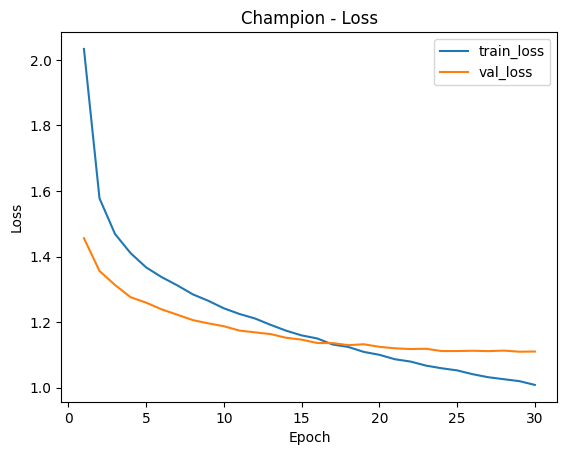

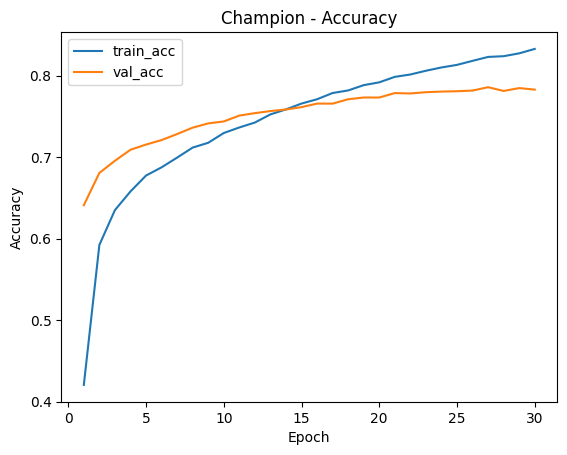


Best Validation Accuracies:
Pancake : 0.7742621534400516
Tower   : 0.7717447926600774
Champion: 0.7858072916666666
Saved champion weights to champion_mlp.pth


In [ ]:
# Train (keeping total epochs <= 40 as required)

EPOCHS_PANCAKE = min(EPOCHS, 20)
EPOCHS_TOWER   = min(EPOCHS, 30)
EPOCHS_CHAMP   = min(EPOCHS, 30)

# Pancake
pancake, hist_p, best_p = train_model(
    pancake, train_loader, val_loader,
    device=DEVICE,
    epochs=EPOCHS_PANCAKE,
    lr=2e-3,
    weight_decay=1e-3,
    patience=6,
    use_scheduler=True,
    model_name="Pancake"
)
plot_curves(hist_p, "Pancake")

# Tower
tower, hist_t, best_t = train_model(
    tower, train_loader, val_loader,
    device=DEVICE,
    epochs=EPOCHS_TOWER,
    lr=1e-3,
    weight_decay=2e-3,
    patience=7,
    use_scheduler=True,
    model_name="Tower"
)
plot_curves(hist_t, "Tower")

# Champion
champion, hist_c, best_c = train_model(
    champion, train_loader, val_loader,
    device=DEVICE,
    epochs=EPOCHS_CHAMP,
    lr=7e-4,
    weight_decay=1e-3,
    patience=8,
    use_scheduler=True,
    model_name="Champion"
)
plot_curves(hist_c, "Champion")

print("\nBest Validation Accuracies:")
print("Pancake :", best_p)
print("Tower   :", best_t)
print("Champion:", best_c)

# Saving champion weights
torch.save(champion.state_dict(), "champion_mlp.pth")
print("Saved champion weights to champion_mlp.pth")

<Figure size 1000x1000 with 0 Axes>

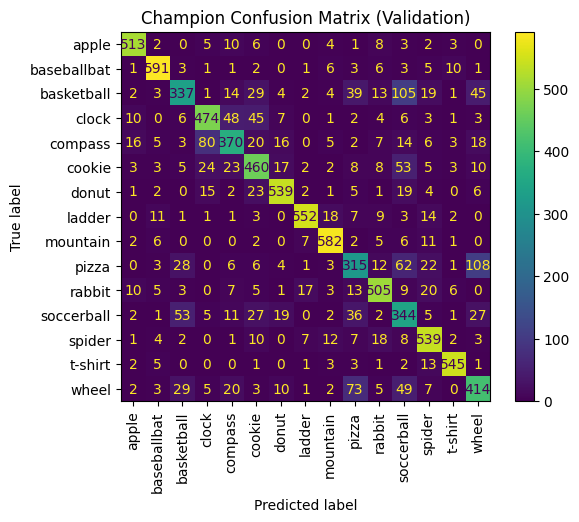


Top-2 confused pairs (directional count shown):
  pizza vs wheel : 108
  basketball vs soccerball : 105


In [ ]:
# Confusion Matrix (Champion on validation set)
@torch.no_grad()
def get_preds_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_y = []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_y.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_y)

val_preds, val_true = get_preds_and_labels(champion, val_loader, DEVICE)
cm = confusion_matrix(val_true, val_preds, labels=list(range(num_classes)))

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_train.classes)
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Champion Confusion Matrix (Validation)")
plt.show()

# Report top-2 confused class pairs
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat_idx = np.argsort(cm_off.ravel())[::-1]
top_pairs = []
seen = set()
for idx in flat_idx:
    i = idx // num_classes
    j = idx % num_classes
    if cm_off[i, j] == 0:
        break
    # treat (i,j) and (j,i) as same pair for reporting
    pair = tuple(sorted((i, j)))
    if pair in seen:
        continue
    seen.add(pair)
    top_pairs.append((i, j, cm_off[i, j]))
    if len(top_pairs) == 2:
        break

print("\nTop-2 confused pairs (directional count shown):")
for i, j, c in top_pairs:
    print(f"  {full_train.classes[i]} vs {full_train.classes[j]} : {c}")

In [ ]:
# Test-set inference
@torch.no_grad()
def predict_test(model, loader, device):
    model.eval()
    preds = []
    for x in loader:
        # test loader returns only images
        x = x.to(device)
        logits = model(x)
        p = torch.argmax(logits, dim=1).cpu().numpy()
        preds.append(p)
    return np.concatenate(preds)

test_preds = predict_test(champion, test_loader, DEVICE)

# CSV-style output required by leaderboard portal
pred_csv = ",".join(map(str, test_preds.tolist()))
print("\n=== COPY THIS INTO LEADERBOARD (predictions) ===")
print(pred_csv[:500] + " ...")  # preview
print(f"\nTotal test predictions: {len(test_preds)}")

# Also save to file for convenience
with open("test_predictions.csv", "w") as f:
    f.write(pred_csv)
print("Saved test predictions to test_predictions.csv")


=== COPY THIS INTO LEADERBOARD (predictions) ===
6,11,5,13,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,5,13,6,14,8,0,13,13,2,6,5,9,10,1,12,13,5,14,5,8,2,12,8,0,2,13,1,11,9,10,1,5,11,0,2,5,11,11,6,10,2,9,6,7,2,0,12,14,12,4,11,4,6,3,9,0,6,5,6,2,11,10,13,6,4,12,0,0,2,2,11,0,7,1,14,3,6,5,12,9,10,14,12,1,6,5,9,7,4,14,11,9,1,8,13,12,2,1,7,11,0,4,7,14,2,13,13,7,14,3,4,5,3,0,8,14,11,11,12,1,13,10,9,1,14,1,12,7,9,3,0,11,14,1,12,6,0,0,2,9,6,0,9,5,13,9,13,5,6,1,5,12,10,4,4,13,7,14,11,7,11,2,13,10,3,12,3,8,6,2,1,14,9,8,6,0,4,1,5,5,2,6,14,10,1,13,1,1,10,5,7,14,5 ...

Total test predictions: 15000
Saved test predictions to test_predictions.csv


In [ ]:
# Summary table print
summary_rows = [
    ("Pancake", count_params(pancake), len(hist_p["train_loss"]), best_p),
    ("Tower",   count_params(tower),   len(hist_t["train_loss"]), best_t),
    ("Champion",count_params(champion),len(hist_c["train_loss"]), best_c),
]
print("\nModel Comparison (Params / Epochs / Best Val Acc):")
for r in summary_rows:
    print(f"{r[0]:8s} | params={r[1]:,} | epochs={r[2]:2d} | best_val_acc={r[3]:.4f}")


Model Comparison (Params / Epochs / Best Val Acc):
Pancake  | params=819,215 | epochs=20 | best_val_acc=0.7743
Tower    | params=536,847 | epochs=30 | best_val_acc=0.7717
Champion | params=604,943 | epochs=30 | best_val_acc=0.7858


In [ ]:


# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
model = champion
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [ ]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 604,943
  ✅ Parameter count is within limits.


In [ ]:
import os
print("Current folder:", os.getcwd())
print(os.listdir())

Current folder: /content
['.config', 'champion_mlp.pth', '.ipynb_checkpoints', 'test_predictions.csv', 'submission.txt', 'processed_data', 'sample_data']


In [ ]:
import numpy as np

data = np.load("/content/processed_data/quickdraw_train.npz", allow_pickle=True)
print(data.files)

['x_train', 'y_train', 'class_names']


In [ ]:
X = data['x_train']
y = data['y_train']
class_names = data['class_names']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(class_names))

X shape: (60000, 784)
y shape: (60000,)
Number of classes: 15


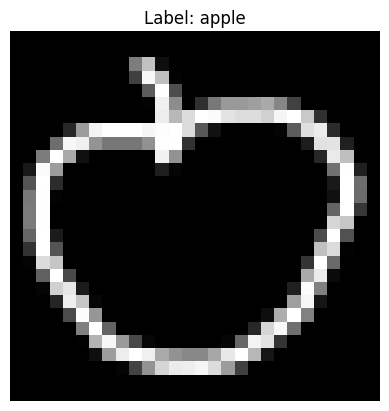

In [ ]:
import matplotlib.pyplot as plt

# pick any index
idx = 0

image = X[idx].reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.title(f"Label: {class_names[y[idx]]}")
plt.axis('off')
plt.show()

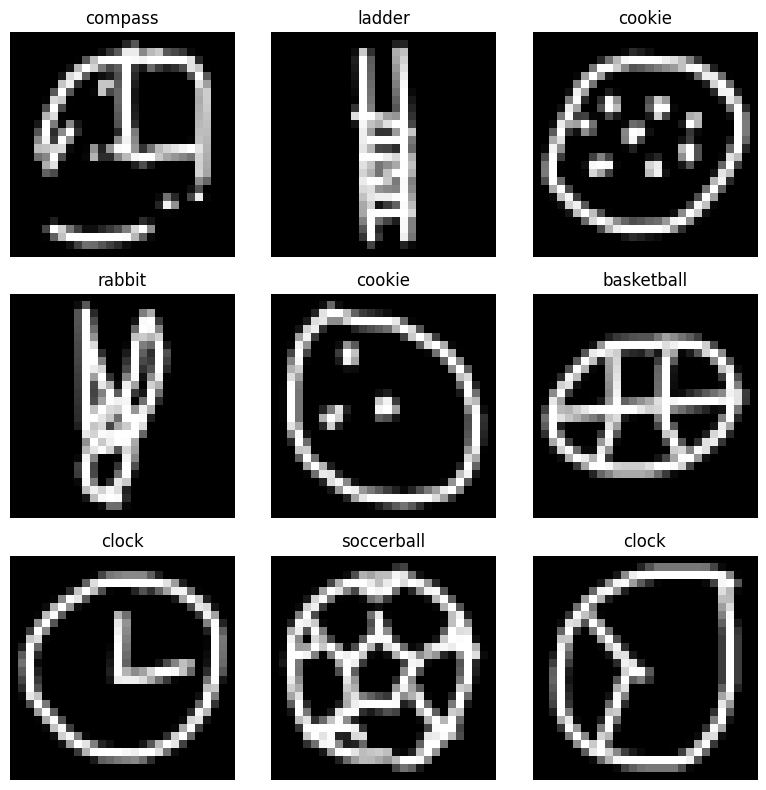

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    idx = np.random.randint(0, len(X))
    plt.imshow(X[idx].reshape(28,28), cmap='gray')
    plt.title(class_names[y[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

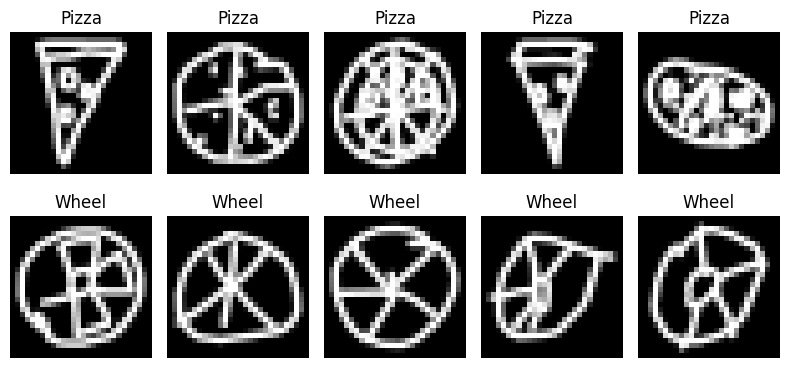

In [ ]:
pizza_idx = np.where(y == list(class_names).index("pizza"))[0]
wheel_idx = np.where(y == list(class_names).index("wheel"))[0]

plt.figure(figsize=(8,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X[pizza_idx[i]].reshape(28,28), cmap='gray')
    plt.title("Pizza")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(X[wheel_idx[i]].reshape(28,28), cmap='gray')
    plt.title("Wheel")
    plt.axis('off')

plt.tight_layout()
plt.show()

Keys in train file: ['x_train', 'y_train', 'class_names']


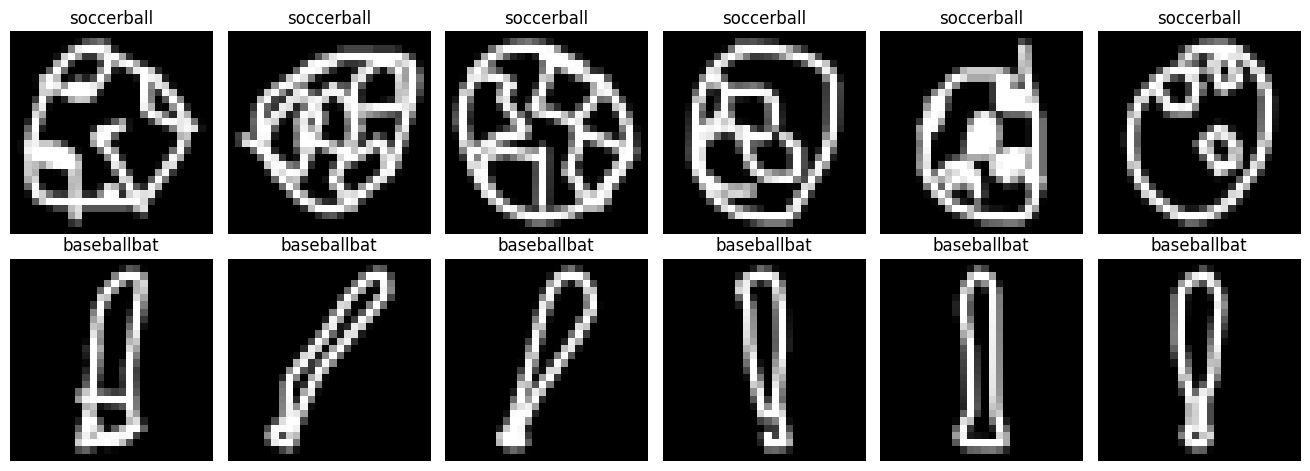

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ✅ Use TRAIN file (must contain x_train/y_train/class_names)
train_path = "/content/processed_data/quickdraw_train.npz"   # <-- change if needed
d = np.load(train_path, allow_pickle=True)

print("Keys in train file:", d.files)

X = d["x_train"]
y = d["y_train"]
class_names = d["class_names"]

# label IDs
soccer_id = int(np.where(class_names == "soccerball")[0][0])
bat_id    = int(np.where(class_names == "baseballbat")[0][0])

soccer_idx = np.where(y == soccer_id)[0]
bat_idx    = np.where(y == bat_id)[0]

# plot samples
n = 6
plt.figure(figsize=(2.2*n, 4.8))

for i in range(n):
    s = np.random.choice(soccer_idx)
    b = np.random.choice(bat_idx)

    plt.subplot(2, n, i + 1)
    plt.imshow(X[s].reshape(28, 28), cmap="gray")
    plt.title("soccerball")
    plt.axis("off")

    plt.subplot(2, n, n + i + 1)
    plt.imshow(X[b].reshape(28, 28), cmap="gray")
    plt.title("baseballbat")
    plt.axis("off")

plt.tight_layout()
plt.show()